# k-Nearest Neighbors

In [1]:
import numpy as np
import pandas as pd
import hashlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split


Function to create the watermark for evry plot i generate

In [2]:
def add_watermark(fig):
    fig.text(
        0.95, 0.95, "harshit.goyal",
        ha='right', va='top',
        fontsize=10, color='gray', alpha=0.7
    )

 Generating a personalised random seed

In [3]:
username = "harshit.goyal"
seed = int(hashlib.sha256(username.encode()).hexdigest(), 16) % (2**32)
# print(seed)

In [ ]:
class PerFeatureTransformer:
    """
    A transformer that applies different preprocessing techniques to each feature.
    It supports standard scaling, ordinal encoding, and one-hot encoding.
    """
    def __init__(self):
        """
        Initializes memory for per-feature transformers.
        """
        self.transformer = {}

    def fit(self, df: pd.DataFrame, params: dict[str, str]) ->None:
        """
        Fits transformers for each feature based on the given type.
        Parameters:
        df: The dataframe containing features to be transformed.
        params: A dictionary mapping feature name to transformation type,
        e.g., {"GPA": "standard", "major": "ordinal", "program": "onehot"}.
        """
        transformer_map = {
            "standard": StandardScaler,
            "ordinal": OrdinalEncoder,
            "onehot": lambda: OneHotEncoder(sparse_output=False, handle_unknown="ignore")
        }
    
        for col, t_type in params.items():
            if t_type not in transformer_map:
                raise ValueError(f"Unknown transform type {t_type}")
            
            transformer = transformer_map[t_type]()
            transformer.fit(df[[col]])
            self.transformer[col] = (t_type, transformer)

    def transform(self, df: pd.DataFrame) -> np.ndarray:
        """
        Applies the fitted transformers to the corresponding
        features and returns a NumPy array.
        """
        arrays = []
        for col, (t_type, transformer) in self.transformer.items():
            arr = transformer.transform(df[[col]])
            arrays.append(arr)
        return np.hstack(arrays)

    def fit_transform(self, df: pd.DataFrame, params: dict[str, str]) -> np.ndarray:
        """
        Fits and transforms all features in one step using the
        given transformation parameters.
        """
        self.fit(df, params)
        return self.transform(df)


In [ ]:
class KNNGenderPredictor:
    """
    A class to predict student gender using a K-Nearest Neighbors classifier.

    This class includes the entire workflow of training, validating, and
    testing a KNN model for gender prediction based on student attributes
    like GPA, major, and program.
    """
    def __init__(self, data: pd.DataFrame):
        """
        Initializes the predictor with the full student dataset.
        Argument = data: pd.DataFrame which contains student data
        """
        self.data = data
        self.pft = PerFeatureTransformer()
        self.splits = {}

    def train_val_test_split(self, test_size:float=0.2, valid_size:float=0.2, seed:int=42) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
        """
        it splits the dataset into train, validation, and test sets.
        Arguments:
            test_size: The proportion of the dataset to allocate to the test set.
            valid_size: The proportion of the remaining training data to allocate to the validation set.
            seed: The random seed for reproducibility.

        Returns a tuple containing the training, validation, and test DataFrames.
        """
        train_df, test_df = train_test_split(self.data, test_size=test_size, random_state=seed)
        train_df, valid_df = train_test_split(train_df, test_size=valid_size, random_state=seed)
        self.splits = {"train": train_df, "val": valid_df, "test": test_df}
        return train_df, valid_df, test_df

    def get_feature_matrix_and_labels(self, df:pd.DataFrame, features:list[str]) -> tuple[np.ndarray, np.ndarray]:
        """
        Extract selected features and gender labels from the DataFrame.
        Applies encoding to categorical variables and normalizes
        numeric features. Do not fit encoders or scalers on test
        data. Only transform using previously fitted ones.
        Arguments:
            df: The DataFrame to process (e.g., training, validation, or test set).
            features: A list of column names to be used as features.

        Returns a tuple (X, y) where X is the transformed feature matrix and y is the
        array of labels.
        """
        X = self.pft.transform(df[features])
        y = df["Gender"].values
        return X, y

    def get_knn_accuracy_vs_k(self, X_train, y_train, X_val, y_val, k_values, distance:str="euclidean") -> list[float]:
        """
        Calculates accuracy scores for various k values on the
        validation set.
        Arguments:
            X_train: The training feature matrix.
            y_train: The training labels.
            X_val: The validation feature matrix.
            y_val: The validation labels.
            k_values: A list or range of k values to test.
            distance: The distance metric to use for the KNN classifier.

        Returns a list of accuracy scores corresponding to each k value.
        """
        scores = []
        for k in k_values:
            knn = KNeighborsClassifier(n_neighbors=k, metric=distance)
            knn.fit(X_train, y_train)
            preds = knn.predict(X_val)
            acc = accuracy_score(y_val, preds)
            scores.append(acc)
        return scores

    def plot_knn_accuracy_vs_k(self, k_values, scores, distance:str="euclidean") -> None:
        """"
        Plots accuracy scores against k values on the validation set.
        Arguments:
            k_values: The list of k values used.
            scores: The list of corresponding accuracy scores.
            distance: The distance metric used, for labeling the plot.
        """
        fig, ax = plt.subplots(figsize=(6, 6))
        add_watermark(fig)
        ax.plot(k_values, scores, marker="x")
        ax.set_xlabel("k (Number of Neighbors)")
        ax.set_ylabel("Model Validation Accuracy")
        ax.set_title(f"KNN Accuracy vs k (Distance Metric: {distance})")
        ax.set_xticks(k_values)
        plt.show()

    def get_knn_f1_heatmap(self, X_train, y_train, X_val, y_val, k_values, distances:list[str]) -> pd.DataFrame:
        """
        Returns a dataframe with the f1-score for each combination on the validation set
        Arguments:
            X_train: The training feature matrix.
            y_train: The training labels.
            X_val: The validation feature matrix.
            y_val: The validation labels.
            k_values: A list of k values to test.
            distances: A list of distance metrics to test.

        Returns a pandas DataFrame with k values as the index, distance metrics as
        columns, and F1 scores as the values.
        """
        results = {}
        for d in distances:
            f1s = []
            for k in k_values:
                knn = KNeighborsClassifier(n_neighbors=k, metric=d)
                knn.fit(X_train, y_train)
                preds = knn.predict(X_val)
                f1 = f1_score(y_val, preds, average="weighted")
                f1s.append(f1)
            results[d] = f1s
        return pd.DataFrame(results, index=k_values)

    def plot_knn_f1_heatmap(self, f1_scores_df:pd.DataFrame) -> None:
        """
        Plots a heatmap of F1 scores.
        Arguments:
            f1_scores_df: A DataFrame of F1 scores, typically from get_knn_f1_heatmap.
        """
        fig, ax = plt.subplots(figsize=(9, 6))
        add_watermark(fig)
        sns.heatmap(f1_scores_df.T, annot=True, cmap="crest", ax=ax)
        ax.set_xlabel("k (Number of Neighbors)")
        ax.set_ylabel("Distance Metric")
        ax.set_title("F1 Score Heatmap")
        plt.show()

    def get_knn_f1_single_feature_table(self, features:list[str], k_values:list[int], distance:str="euclidean") -> pd.DataFrame:
            """
            Creates a table of F1 scores on the test set using only a
            single feature for prediction.
            Arguments:
                features: A list of individual feature names to test.
                k_values: A list of k values to test for each feature.
                distance: The distance metric to use for the KNN classifier.

            Returns a pandas DataFrame with k values as the index, feature names as
            columns, and the corresponding F1 scores as values.
            """
            results = {}
            y_train = self.splits["train"]["Gender"].values
            y_test = self.splits["test"]["Gender"].values

            for feat in features:
                local_pft = PerFeatureTransformer()
                transform_type = "standard" if pd.api.types.is_numeric_dtype(self.splits["train"][feat]) else "onehot"
                X_train_single = local_pft.fit_transform(self.splits["train"][[feat]], {feat: transform_type})
                X_test_single = local_pft.transform(self.splits["test"][[feat]])
                
                f1s = [
                    f1_score(y_test, KNeighborsClassifier(n_neighbors=k, metric=distance).fit(X_train_single, y_train).predict(X_test_single), average="weighted")
                    for k in k_values
                ]
                results[feat] = f1s
            return pd.DataFrame(results, index=k_values)


In [6]:
data = pd.read_csv("student_dataset.csv")
predictor = KNNGenderPredictor(data)

train_df, valid_df, test_df = predictor.train_val_test_split(seed=seed)

params = {"GPA": "standard", "Major": "onehot", "Program": "onehot"}
predictor.pft.fit(train_df[list(params.keys())], params)

X_train, y_train = predictor.get_feature_matrix_and_labels(train_df, list(params.keys()))
X_val, y_val = predictor.get_feature_matrix_and_labels(valid_df, list(params.keys()))
X_test, y_test = predictor.get_feature_matrix_and_labels(test_df, list(params.keys()))


Max k value: 21 with accuracy 0.6181


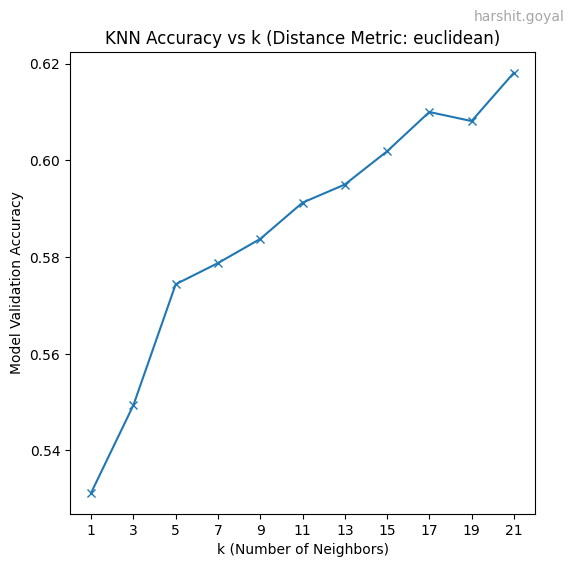

In [7]:
k_values = list(range(1, 22, 2))
scores = predictor.get_knn_accuracy_vs_k(X_train, y_train, X_val, y_val, k_values, distance="euclidean")
max_kvalue = k_values[scores.index(max(scores))]
print(f"Max k value: {max_kvalue} with accuracy {max(scores):.4f}")
predictor.plot_knn_accuracy_vs_k(k_values, scores, distance="euclidean")


Max k value: 21 with accuracy 0.6181


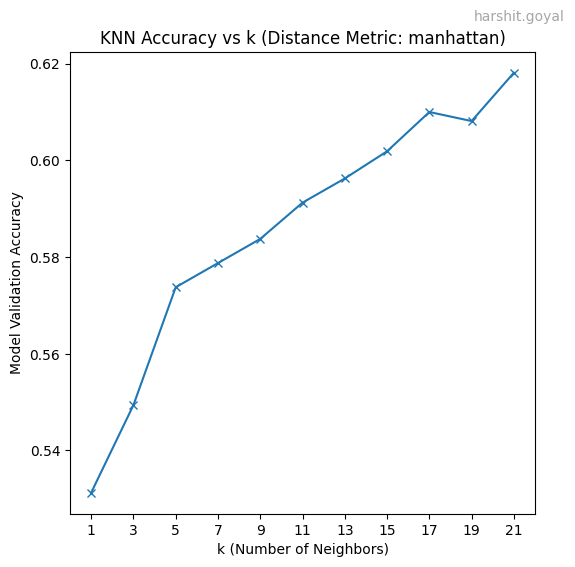

In [8]:
k_values = list(range(1, 22, 2))
scores = predictor.get_knn_accuracy_vs_k(X_train, y_train, X_val, y_val, k_values, distance="manhattan")
max_kvalue = k_values[scores.index(max(scores))]
print(f"Max k value: {max_kvalue} with accuracy {max(scores):.4f}")
predictor.plot_knn_accuracy_vs_k(k_values, scores, distance="manhattan")

Max k value: 21 with accuracy 0.6181


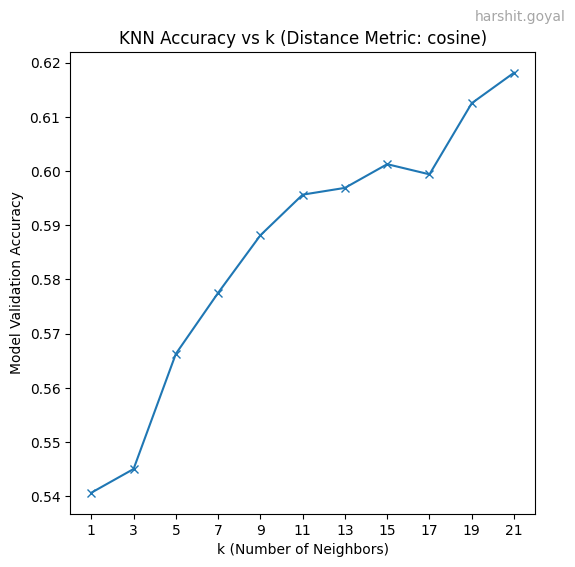

In [9]:
k_values = list(range(1, 22, 2))
scores = predictor.get_knn_accuracy_vs_k(X_train, y_train, X_val, y_val, k_values, distance="cosine")
max_kvalue = k_values[scores.index(max(scores))]
print(f"Max k value: {max_kvalue} with accuracy {max(scores):.4f}")
predictor.plot_knn_accuracy_vs_k(k_values, scores, distance="cosine")

In [10]:
pd.set_option('display.precision', 10)
distances = ["euclidean", "manhattan", "cosine"]
f1_df = predictor.get_knn_f1_heatmap(X_train, y_train, X_val, y_val, k_values, distances)
print("F1 Score Heatmap DataFrame:")
print(f1_df)


F1 Score Heatmap DataFrame:
       euclidean     manhattan        cosine
1   0.5252213918  0.5252213918  0.5346588417
3   0.5312980960  0.5312980960  0.5258482286
5   0.5402093521  0.5396472938  0.5363224358
7   0.5402722770  0.5406829009  0.5348999350
9   0.5342790260  0.5342790260  0.5343574085
11  0.5310694903  0.5310694903  0.5361630587
13  0.5268669251  0.5289070940  0.5256292105
15  0.5270844771  0.5277330939  0.5223346092
17  0.5279059809  0.5272052232  0.5162839953
19  0.5162231427  0.5162231427  0.5205505315
21  0.5214765545  0.5222735060  0.5209375983


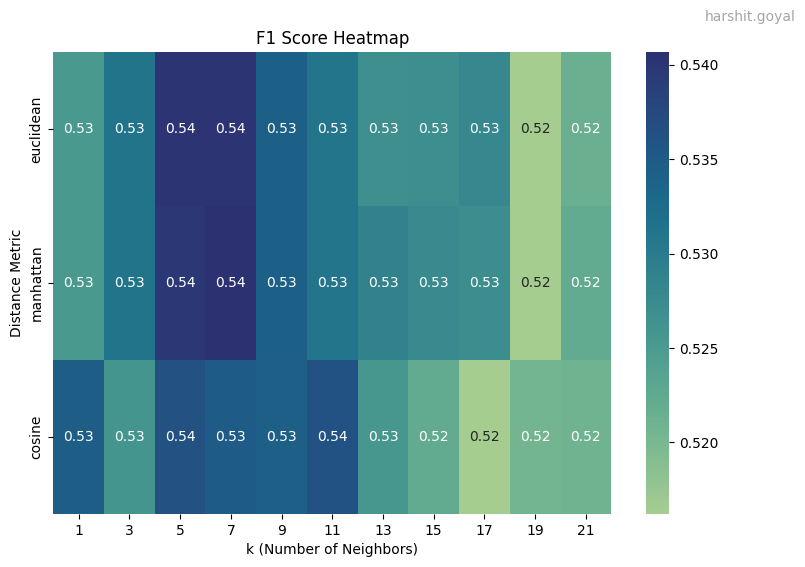

In [11]:
predictor.plot_knn_f1_heatmap(f1_df)

In [12]:
# find the best k and metric combination with max f1 score
max_f1_score = f1_df.max().max()
best_k, best_metric = f1_df.stack().idxmax()

print(f"\nBest combination based on F1 score:")
print(f"  - Metric: {best_metric}")
print(f"  - k: {best_k}")
print(f"  - Max F1 Score: {max_f1_score}")


Best combination based on F1 score:
  - Metric: manhattan
  - k: 7
  - Max F1 Score: 0.5406829009065333


Based on the F1 score results:
Manhattan distance performs better than Euclidean and Cosine for this dataset.
This is likely because Manhattan distance (L1 norm) measures the absolute differences across each feature dimension, which can be more robust when the data has features with different scales or when the distribution of values is not smooth and continuous. Unlike Euclidean distance, which squares the differences and can be overly influenced by large deviations in a single feature, Manhattan treats all deviations linearly, making it less sensitive to outliers. Compared to cosine similarity, Manhattan considers the actual magnitude of the feature differences, which may capture more discriminative information in this dataset where the absolute values of features are important for classification.

In [13]:
features = ["GPA", "Major", "Program"]
Single_feature = {}

for dist in distances:
    print(f"\n--- Single Feature F1 Table (distance = {dist}) ---")
    f1_table = predictor.get_knn_f1_single_feature_table(features, k_values, distance=dist)
    Single_feature[dist] = f1_table
    print(f1_table)



--- Single Feature F1 Table (distance = euclidean) ---
             GPA         Major       Program
1   0.5350950681  0.5493922641  0.4336766789
3   0.5534473294  0.5058054711  0.5363629277
5   0.5562236135  0.5058054711  0.5363629277
7   0.5413402696  0.5058054711  0.5363629277
9   0.5406775314  0.5058054711  0.5363629277
11  0.5398050556  0.5058054711  0.5363629277
13  0.5335989533  0.5058054711  0.5058054711
15  0.5277792650  0.5058054711  0.5300291120
17  0.5281430782  0.5058054711  0.5363629277
19  0.5249796872  0.5058054711  0.5058054711
21  0.5268333420  0.5058054711  0.5058054711

--- Single Feature F1 Table (distance = manhattan) ---
             GPA         Major       Program
1   0.5350950681  0.5493922641  0.4336766789
3   0.5534473294  0.5058054711  0.5363629277
5   0.5562236135  0.5058054711  0.5363629277
7   0.5413402696  0.5058054711  0.5363629277
9   0.5406775314  0.5058054711  0.5363629277
11  0.5398050556  0.5058054711  0.5363629277
13  0.5335989533  0.5058054711  0

In [14]:
summary = []

for dist, f1_table in Single_feature.items():
    max_f1_score = f1_table.max().max()
    best_k, best_feature = f1_table.stack().idxmax()
    
    summary.append({"Distance Metric": dist,"Best Feature": best_feature,"Best k": best_k,"Max F1 Score": max_f1_score})

summary_df = pd.DataFrame(summary)

# Print the final summary table
print("\n--- Overall Best Feature, k, and F1 Score per Distance Metric ---")
print(summary_df.to_string(index=False))

max_f1_score_all = f1_df.max().max()
max_f1_metric_all = f1_df.stack().idxmax()
print(f"\nOverall Max F1 Score across all metrics using all features : {max_f1_score_all} with (k, metric) = {max_f1_metric_all}")



--- Overall Best Feature, k, and F1 Score per Distance Metric ---
Distance Metric Best Feature  Best k  Max F1 Score
      euclidean          GPA       5  0.5562236135
      manhattan          GPA       5  0.5562236135
         cosine        Major       3  0.5368176674

Overall Max F1 Score across all metrics using all features : 0.5406829009065333 with (k, metric) = (7, 'manhattan')


The single feature GPA with Euclidean/Manhattan distance achieved the highest F1 score (≈0.556), which is slightly better than using all features together (≈0.541). This suggests that GPA alone provides the strongest discriminative signal for classification, while adding Major and Program may introduce redundancy or noise that lowers performance. In this case, the absolute differences in GPA values capture the separation between classes more effectively than the categorical features. Furthermore, including all features increases dimensionality, which can dilute the effectiveness of distance-based metrics (a manifestation of the curse of dimensionality). Thus, the single dominant feature (GPA) can outperform the combination of all features.